In [3]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,make_scorer
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

Loading data

In [5]:
target_train = pd.read_parquet("../data/target_train.parquet")
network_train = pd.read_parquet("../data/network_train.parquet")
weather_train = pd.read_parquet("../data/weather_train.parquet")
weather_test = pd.read_parquet("../data/weather_test.parquet")
network_test = pd.read_parquet("../data/network_test.parquet")

In [ ]:
from preprocessing import prepare_weather

weather_flat = prepare_weather(weather_train)

In [6]:
target_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43849 entries, 2020-01-01 00:00:00+00:00 to 2025-01-01 00:00:00+00:00
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   FR_load_actual   43785 non-null  float32
 1   FR_price_actual  43849 non-null  float32
 2   FR_solar_actual  43105 non-null  float32
 3   FR_wind_actual   43705 non-null  float32
dtypes: float32(4)
memory usage: 1.0 MB


There are missing data in all target columns. They need to be interpolated

In [7]:
network_train.info()
#no missing data

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43849 entries, 2020-01-01 00:00:00+00:00 to 2025-01-01 00:00:00+00:00
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EEX_CARBON               43849 non-null  float32
 1   EEX_COAL                 43849 non-null  float32
 2   EEX_GAS_PEG              43849 non-null  float32
 3   FR_capacity_solar        43849 non-null  float32
 4   FR_capacity_wind         43849 non-null  float32
 5   FR_availability_coal     43849 non-null  float32
 6   FR_availability_gas      43849 non-null  float32
 7   FR_availability_hydro    43849 non-null  float32
 8   FR_availability_nuclear  43849 non-null  float32
dtypes: float32(9)
memory usage: 1.8 MB


Lags

In [20]:
weather_flat["ssrd_lag1"] = weather_flat["ssrd_mean"].shift(1)
weather_flat["ssrd_lag24"] = weather_flat["ssrd_mean"].shift(24)


rolling window

In [21]:
weather_flat["ssrd_roll_3h"] = weather_flat["ssrd_mean"].rolling(3).mean()
weather_flat["ssrd_roll_24h"] = weather_flat["ssrd_mean"].rolling(24).mean()

In [22]:
weather_flat["tcc_roll_6h_std"] = weather_flat["tcc_mean"].rolling(6).std()

In [23]:
weather_flat = weather_flat.dropna()

In [24]:
weather_flat["hour"] = weather_flat.index.hour


In [25]:
weather_flat["month"] = weather_flat.index.month

In [26]:
weather_flat["hour"]

,hour
start_date,
2020-01-02 00:00:00+00:00,0
2020-01-02 01:00:00+00:00,1
2020-01-02 02:00:00+00:00,2
2020-01-02 03:00:00+00:00,3
2020-01-02 04:00:00+00:00,4
...,...
2024-12-31 20:00:00+00:00,20
2024-12-31 21:00:00+00:00,21
2024-12-31 22:00:00+00:00,22


In [27]:


weather_flat["hour_sin"] = np.sin(2 * np.pi * weather_flat["hour"] / 24)
weather_flat["hour_cos"] = np.cos(2 * np.pi * weather_flat["hour"] / 24)

weather_flat["month_sin"] = np.sin(2 * np.pi * weather_flat["month"] / 12)
weather_flat["month_cos"] = np.cos(2 * np.pi * weather_flat["month"] / 12)

In [28]:
weather_flat["ssrd_norm"] = weather_flat["ssrd_mean"] / weather_flat["ssrd_mean"].max()
weather_flat["solar_potential"] = weather_flat["ssrd_norm"] * (1 - weather_flat["tcc_mean"])

In [29]:
weather_flat.head(20)

,ssrd_mean,ssrd_std,tcc_mean,tcc_std,temp_mean,wind_mean,wind_std,ssrd_lag1,ssrd_lag24,ssrd_roll_3h,ssrd_roll_24h,tcc_roll_6h_std,hour,month,hour_sin,hour_cos,month_sin,month_cos,ssrd_norm,solar_potential
start_date,,,,,,,,,,,,,,,,,,,,
2020-01-02 00:00:00+00:00,0.000000,0.000000,0.591098,0.397544,4.024190,3.861214,2.025915,0.000000,0.000000,0.000000,131455.535257,0.019537,0,1,0.000000e+00,1.000000e+00,0.5,0.866025,0.000000e+00,0.000000e+00
2020-01-02 01:00:00+00:00,0.000000,0.000000,0.626592,0.391434,3.880080,4.081434,2.093134,0.000000,0.000000,0.000000,131455.535257,0.021942,1,1,2.588190e-01,9.659258e-01,0.5,0.866025,0.000000e+00,0.000000e+00
2020-01-02 02:00:00+00:00,0.000000,0.000000,0.647933,0.395149,3.885397,4.182189,2.126657,0.000000,0.000000,0.000000,131455.535257,0.033401,2,1,5.000000e-01,8.660254e-01,0.5,0.866025,0.000000e+00,0.000000e+00
2020-01-02 03:00:00+00:00,0.000000,0.000000,0.652530,0.402927,3.899515,4.303050,2.085833,0.000000,0.000000,0.000000,131455.535257,0.038484,3,1,7.071068e-01,7.071068e-01,0.5,0.866025,0.000000e+00,0.000000e+00
2020-01-02 04:00:00+00:00,0.000000,0.000000,0.651431,0.406992,3.928852,4.358646,2.013896,0.000000,0.000000,0.000000,131455.535257,0.035472,4,1,8.660254e-01,5.000000e-01,0.5,0.866025,0.000000e+00,0.000000e+00
2020-01-02 05:00:00+00:00,0.000000,0.000000,0.651239,0.404007,3.969339,4.461545,1.989101,0.000000,0.000000,0.000000,131455.535257,0.024441,5,1,9.659258e-01,2.588190e-01,0.5,0.866025,0.000000e+00,0.000000e+00
2020-01-02 06:00:00+00:00,0.000000,0.000000,0.646981,0.410817,4.030849,4.680801,1.992654,0.000000,0.000000,0.000000,131455.535257,0.009807,6,1,1.000000e+00,6.123234e-17,0.5,0.866025,0.000000e+00,0.000000e+00
2020-01-02 07:00:00+00:00,0.597015,9.773517,0.626321,0.413303,4.160176,4.871316,2.011452,0.000000,0.597015,0.199005,131455.535257,0.009915,7,1,9.659258e-01,-2.588190e-01,0.5,0.866025,1.828121e-07,6.831304e-08
2020-01-02 08:00:00+00:00,15869.246094,25658.123047,0.600361,0.412264,4.533415,5.029793,2.020888,0.597015,17589.734375,5289.947703,131383.848246,0.020978,8,1,8.660254e-01,-5.000000e-01,0.5,0.866025,4.859325e-03,1.941975e-03


In [30]:
weather_flat.describe()

,ssrd_mean,ssrd_std,tcc_mean,tcc_std,temp_mean,wind_mean,wind_std,ssrd_lag1,ssrd_lag24,ssrd_roll_3h,ssrd_roll_24h,tcc_roll_6h_std,hour,month,hour_sin,hour_cos,month_sin,month_cos,ssrd_norm,solar_potential
count,4.382500e+04,4.382500e+04,43825.000000,43825.000000,43825.000000,43825.000000,43825.000000,4.382500e+04,4.382500e+04,4.382500e+04,4.382500e+04,43825.000000,43825.000000,43825.000000,4.382500e+04,4.382500e+04,4.382500e+04,4.382500e+04,43825.000000,43825.000000
mean,5.279838e+05,1.880335e+05,0.591495,0.319816,12.967485,5.901623,2.459478,5.279838e+05,5.279527e+05,5.279838e+05,5.279711e+05,0.037846,11.499738,6.523970,-1.888836e-17,2.281803e-05,-4.691910e-03,-2.278189e-03,0.161674,0.071316
std,7.516749e+05,2.530127e+05,0.238603,0.082099,6.582999,2.063228,0.685802,7.516749e+05,7.516815e+05,7.307403e+05,2.978646e+05,0.026820,6.922405,3.447836,7.071068e-01,7.071229e-01,7.059325e-01,7.082760e-01,0.230146,0.130065
min,-3.656997e+01,0.000000e+00,0.003650,0.000060,-3.022623,1.460469,0.708081,-3.656997e+01,-3.656997e+01,-1.218999e+01,3.177082e+03,0.000573,0.000000,1.000000,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-0.000011,-0.000009
25%,0.000000e+00,0.000000e+00,0.425976,0.278113,7.998679,4.405047,1.972465,0.000000e+00,0.000000e+00,0.000000e+00,2.392339e+05,0.018263,5.000000,4.000000,-7.071068e-01,-7.071068e-01,-8.660254e-01,-8.660254e-01,0.000000,0.000000
50%,3.280857e+04,3.114746e+04,0.626358,0.337885,12.468290,5.609735,2.335537,3.280857e+04,3.280857e+04,1.001119e+05,5.173040e+05,0.030969,11.000000,7.000000,0.000000e+00,6.123234e-17,-2.449294e-16,-1.836970e-16,0.010046,0.002399
75%,9.055206e+05,3.365379e+05,0.776461,0.377828,17.826517,7.104646,2.836879,9.055206e+05,9.055206e+05,8.853378e+05,7.686516e+05,0.050317,17.000000,10.000000,7.071068e-01,7.071068e-01,5.000000e-01,8.660254e-01,0.277280,0.088444
max,3.265730e+06,1.252964e+06,0.999996,0.480211,34.918659,16.208658,6.710629,3.265730e+06,3.265730e+06,3.201975e+06,1.223625e+06,0.250257,23.000000,12.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,0.957553


In [31]:
weather_flat.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43825 entries, 2020-01-02 00:00:00+00:00 to 2025-01-01 00:00:00+00:00
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ssrd_mean        43825 non-null  float32
 1   ssrd_std         43825 non-null  float32
 2   tcc_mean         43825 non-null  float32
 3   tcc_std          43825 non-null  float32
 4   temp_mean        43825 non-null  float32
 5   wind_mean        43825 non-null  float32
 6   wind_std         43825 non-null  float32
 7   ssrd_lag1        43825 non-null  float32
 8   ssrd_lag24       43825 non-null  float32
 9   ssrd_roll_3h     43825 non-null  float64
 10  ssrd_roll_24h    43825 non-null  float64
 11  tcc_roll_6h_std  43825 non-null  float64
 12  hour             43825 non-null  int32  
 13  month            43825 non-null  int32  
 14  hour_sin         43825 non-null  float64
 15  hour_cos         43825 non-null  float64
 16  month_sin  

In [32]:
network_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43849 entries, 2020-01-01 00:00:00+00:00 to 2025-01-01 00:00:00+00:00
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EEX_CARBON               43849 non-null  float32
 1   EEX_COAL                 43849 non-null  float32
 2   EEX_GAS_PEG              43849 non-null  float32
 3   FR_capacity_solar        43849 non-null  float32
 4   FR_capacity_wind         43849 non-null  float32
 5   FR_availability_coal     43849 non-null  float32
 6   FR_availability_gas      43849 non-null  float32
 7   FR_availability_hydro    43849 non-null  float32
 8   FR_availability_nuclear  43849 non-null  float32
dtypes: float32(9)
memory usage: 1.8 MB


These 24 missing rows come from the lag and rolling features  created. These features require 24 hours of history, so the first 24 timestamps cannot be computed and were dropped.

In [33]:
X = weather_flat.join(network_train, how="inner")

In [34]:
target_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43849 entries, 2020-01-01 00:00:00+00:00 to 2025-01-01 00:00:00+00:00
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   FR_load_actual   43785 non-null  float32
 1   FR_price_actual  43849 non-null  float32
 2   FR_solar_actual  43105 non-null  float32
 3   FR_wind_actual   43705 non-null  float32
dtypes: float32(4)
memory usage: 1.0 MB


FR_solar_actual  43105 indicate that there are 744 rows missing. I will interpolate the missing values

In [35]:


target_train["FR_solar_actual"] = (
    target_train["FR_solar_actual"]
    .interpolate(method="time")
    .bfill()
    .ffill()
    .clip(lower=0)
)

y=target_train[["FR_solar_actual"]]

In [36]:
solar_df=X.join(y, how="inner")

In [37]:
train = solar_df.loc["2020":"2023"]
valid = solar_df.loc["2024"]

In [38]:
X_train = train.drop('FR_solar_actual', axis=1)
y_train = train['FR_solar_actual']
X_valid = valid.drop('FR_solar_actual', axis=1)
y_valid = valid['FR_solar_actual']

In [39]:
print('training set',train.shape)
print('validation set',valid.shape)

training set (35040, 30)
validation set (8784, 30)


## Model

#LGBM

In [40]:


model_1 = LGBMRegressor(
    objective="regression",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_1.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="rmse",
    callbacks=[]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003362 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5745
[LightGBM] [Info] Number of data points in the train set: 35040, number of used features: 29
[LightGBM] [Info] Start training from score 1880.596062


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=1000,
              num_leaves=64, objective='regression', random_state=42,
              subsample=0.8)

In [41]:
y_pred_train_lgbm = model_1.predict(X_train)

mae_train_lgbm = mean_absolute_error(y_train, y_pred_train_lgbm)
rmse_train_lgbm = np.sqrt(mean_squared_error(y_train, y_pred_train_lgbm))
r2_train_lgbm = r2_score(y_train, y_pred_train_lgbm)

print("LightGBM Model Performance on Training Data:")
print(f"MAE: {mae_train_lgbm}")
print(f"RMSE: {rmse_train_lgbm}")
print(f"R²: {r2_train_lgbm}")


LightGBM Model Performance on Training Data:
MAE: 52.74604637105944
RMSE: 93.25816601524264
R²: 0.9987816436629465


In [42]:
y_pred = model_1.predict(X_valid)

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_valid, y_pred)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
r2 = r2_score(y_valid, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 854.0655155208163
RMSE: 1513.1899055830306
R²: 0.818661009540832


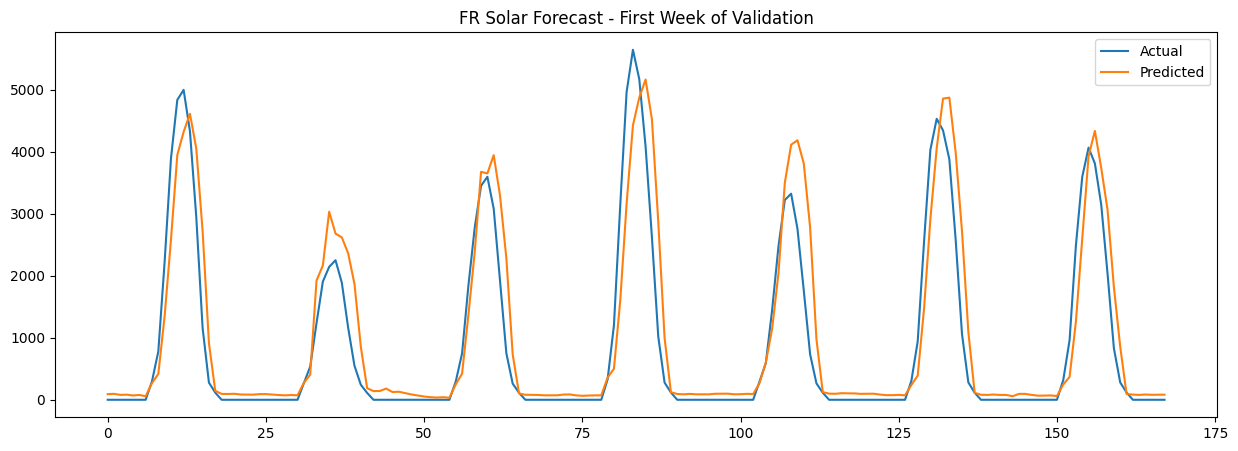

In [ ]:


plt.figure(figsize=(15, 5))
plt.plot(y_valid.iloc[:168].values, label="Actual")      # first week
plt.plot(y_pred[:168], label="Predicted")
plt.legend()
plt.title("FR Solar Forecast - First Week of Validation")
plt.show()

In [44]:


fi = pd.Series(
    model_1.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(fi.head(20))

ssrd_mean                  3563
ssrd_roll_24h              3493
ssrd_std                   3404
wind_mean                  3304
wind_std                   3121
FR_availability_hydro      3108
ssrd_lag24                 3073
FR_availability_nuclear    3047
tcc_mean                   2989
temp_mean                  2825
EEX_CARBON                 2768
solar_potential            2695
tcc_std                    2684
FR_availability_gas        2653
FR_capacity_solar          2603
tcc_roll_6h_std            2507
EEX_COAL                   2335
EEX_GAS_PEG                2286
ssrd_lag1                  2014
hour                       1800
dtype: int32


## XGBoost Model

In [45]:


model_2 = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist')

model_2.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [46]:
y_pred_train_xgb = model_2.predict(X_train)

mae_train_xgb = mean_absolute_error(y_train, y_pred_train_xgb)
rmse_train_xgb = np.sqrt(mean_squared_error(y_train, y_pred_train_xgb))
r2_train_xgb = r2_score(y_train, y_pred_train_xgb)

print("\nTuned XGBoost Model Performance on Training Data:")
print(f"MAE: {mae_train_xgb}")
print(f"RMSE: {rmse_train_xgb}")
print(f"R²: {r2_train_xgb}")


Tuned XGBoost Model Performance on Training Data:
MAE: 41.80451965332031
RMSE: 67.08439399717903
R²: 0.9993695616722107


In [47]:
y_pred_xgb = model_2.predict(X_valid)

In [48]:


mae_xgb = mean_absolute_error(y_valid, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_valid, y_pred_xgb))
r2_xgb = r2_score(y_valid, y_pred_xgb)

print("XGBoost Model Performance:")
print(f"MAE: {mae_xgb}")
print(f"RMSE: {rmse_xgb}")
print(f"R²: {r2_xgb}")

XGBoost Model Performance:
MAE: 875.8025512695312
RMSE: 1538.8961141025732
R²: 0.8124474287033081


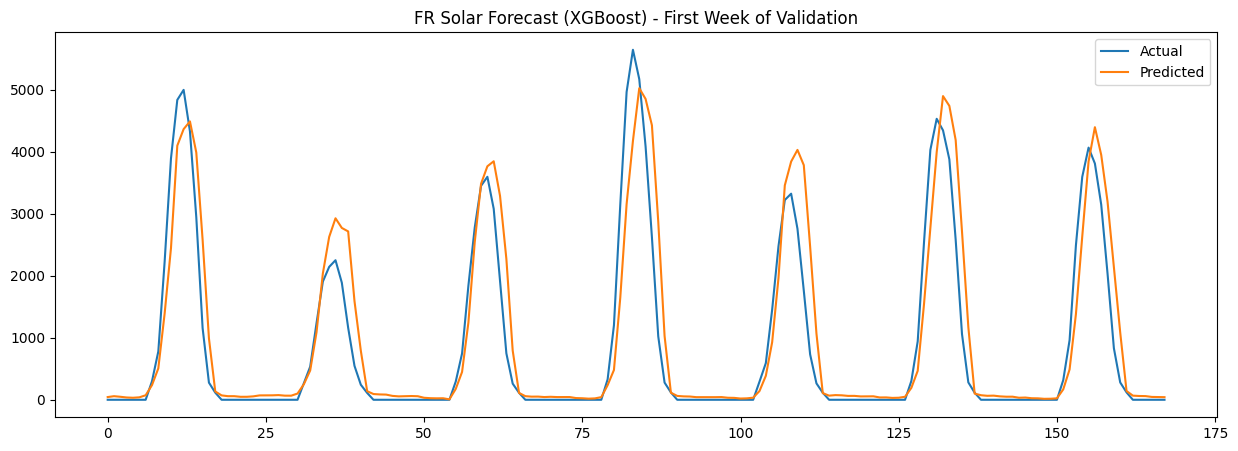

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(y_valid.iloc[:168].values, label="Actual")      # first week
plt.plot(y_pred_xgb[:168], label="Predicted")
plt.legend()
plt.title("FR Solar Forecast (XGBoost) - First Week of Validation")
plt.show()

In [49]:
fi_xgb = pd.Series(
    model_2.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("XGBoost Feature Importances (Top 20):")
print(fi_xgb.head(20))

XGBoost Feature Importances (Top 20):
ssrd_norm                  0.649324
ssrd_mean                  0.168450
hour                       0.052459
FR_capacity_wind           0.032090
FR_capacity_solar          0.030415
ssrd_lag24                 0.022497
solar_potential            0.007267
hour_cos                   0.004699
hour_sin                   0.003556
EEX_COAL                   0.003339
month_sin                  0.002475
ssrd_std                   0.002293
EEX_CARBON                 0.002279
month                      0.002144
month_cos                  0.002113
EEX_GAS_PEG                0.002072
FR_availability_nuclear    0.001808
ssrd_roll_3h               0.001223
tcc_std                    0.001199
FR_availability_gas        0.001115
dtype: float32


## Hyperparameter Tuning for XGBoost using RandomizedSearchCV

In [50]:


# Define the parameter distribution
param_dist = {
    'n_estimators': randint(500, 1500),
    'learning_rate': uniform(0.01, 0.1),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5),
    'lambda': uniform(1, 2) # L2 regularization
}

# Initialize XGBoost Regressor with fixed parameters
# tree_method='hist' for faster training
# objective='reg:squarederror' is default for regression problems
xgb = XGBRegressor(objective='reg:squarederror', random_state=42, tree_method='hist')

# Initialize RandomizedSearchCV
# n_iter: Number of parameter settings that are sampled. More is better but takes longer.
# cv: Number of cross-validation folds
# scoring: Metric to optimize (e.g., 'neg_root_mean_squared_error' for RMSE)
# verbose: Controls the verbosity of the process
# n_jobs: Number of jobs to run in parallel (-1 means using all processors)
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50, # You can increase this for a more thorough search
    cv=3, # Using 3-fold cross-validation
    scoring='neg_root_mean_squared_error', # Optimize for RMSE (negative to maximize)
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit the random search to the data
# We will use the full training data for the search
random_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found: ", random_search.best_params_)
print("Best RMSE found: ", -random_search.best_score_)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best parameters found:  {'colsample_bytree': np.float64(0.6987504251354405), 'gamma': np.float64(0.3481521364198942), 'lambda': np.float64(2.424541179848884), 'learning_rate': np.float64(0.02480869299533999), 'max_depth': 3, 'n_estimators': 1198, 'subsample': np.float64(0.8438257335919588)}
Best RMSE found:  771.573232014974


After finding the best parameters, you can then train a new XGBoost model with these optimal settings and evaluate its performance on the validation set.

In [51]:
# Train a new model with the best parameters
best_xgb_model = random_search.best_estimator_

# Make predictions on the validation set
y_pred_tuned_xgb = best_xgb_model.predict(X_valid)

# Evaluate the tuned model
mae_tuned_xgb = mean_absolute_error(y_valid, y_pred_tuned_xgb)
rmse_tuned_xgb = np.sqrt(mean_squared_error(y_valid, y_pred_tuned_xgb))
r2_tuned_xgb = r2_score(y_valid, y_pred_tuned_xgb)

print("Tuned XGBoost Model Performance:")
print(f"MAE: {mae_tuned_xgb}")
print(f"RMSE: {rmse_tuned_xgb}")
print(f"R²: {r2_tuned_xgb}")

Tuned XGBoost Model Performance:
MAE: 807.8604125976562
RMSE: 1467.581173223478
R²: 0.8294276595115662


In [52]:
y_pred_train_xgb = best_xgb_model.predict(X_train)

mae_train_xgb = mean_absolute_error(y_train, y_pred_train_xgb)
rmse_train_xgb = np.sqrt(mean_squared_error(y_train, y_pred_train_xgb))
r2_train_xgb = r2_score(y_train, y_pred_train_xgb)

print("\nTuned XGBoost Model Performance on Training Data:")
print(f"MAE: {mae_train_xgb}")
print(f"RMSE: {rmse_train_xgb}")
print(f"R²: {r2_train_xgb}")


Tuned XGBoost Model Performance on Training Data:
MAE: 205.37364196777344
RMSE: 368.3021432872744
R²: 0.9809975624084473


/tmp/ipykernel_12241/860205373.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=mae_values, palette='viridis')


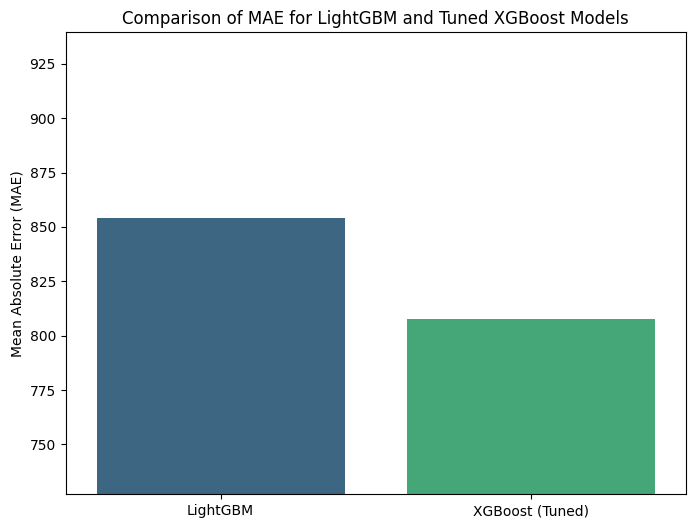

In [54]:
model_names = ['LightGBM', 'XGBoost (Tuned)']
mae_values = [mae, mae_tuned_xgb]

plt.figure(figsize=(8, 6))
sns.barplot(x=model_names, y=mae_values, palette='viridis')
plt.title('Comparison of MAE for LightGBM and Tuned XGBoost Models')
plt.ylabel('Mean Absolute Error (MAE)')
plt.ylim(min(mae_values) * 0.9, max(mae_values) * 1.1)
plt.show()

#Cross validation

Yes, time-series cross-validation will help you obtain more robust validation scores and better hyperparameters. It does not directly prevent overfitting, but it is one of the best ways to detect and reduce it through better model selection.

In [60]:


tscv = TimeSeriesSplit(n_splits=4)

In [62]:
X_cv = solar_df.drop('FR_solar_actual', axis=1)
y_cv = solar_df['FR_solar_actual']

In [63]:
rmse_scorer = make_scorer(
    lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
    greater_is_better=False
)

scores = cross_val_score(
    model_1,
    X_cv,
    y_cv,
    cv=tscv,
    scoring=rmse_scorer
)

print("RMSE per fold:", -scores)
print("Average RMSE:", -scores.mean())

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000767 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5584
[LightGBM] [Info] Number of data points in the train set: 8765, number of used features: 29
[LightGBM] [Info] Start training from score 1414.603366
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001521 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5717
[LightGBM] [Info] Number of data points in the train set: 17530, number of used features: 29
[LightGBM] [Info] Start training from score 1486.018340
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016404 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Tot

In [64]:
r2_scorer = make_scorer(r2_score)

r2_scores = cross_val_score(
    model_1,
    X_cv,
    y_cv,
    cv=tscv,
    scoring=r2_scorer
)

print("R-squared per fold:", r2_scores)
print("Average R-squared:", r2_scores.mean())

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000876 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5584
[LightGBM] [Info] Number of data points in the train set: 8765, number of used features: 29
[LightGBM] [Info] Start training from score 1414.603366
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008909 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5717
[LightGBM] [Info] Number of data points in the train set: 17530, number of used features: 29
[LightGBM] [Info] Start training from score 1486.018340
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002234 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Tot